## **Nom Prénom**:  Pembele Luccin

## **Présentation :**
- Le jeu vidéo Fifa permet de controler des joueurs.
- Le jeu donne des statistiques détaillées pour chaque joueurs créant un lien entre le jeu et l'analyse des performances des joueurs
- Elle nous transmet une base de données de 16161 lignes (joueurs) et de 33 colonnes (statistiques/Informations).

## **Problématique :**
Quels sont les facteurs clés influençant la performance et comment ces données peuvent-elles être utilisées pour guider des décisions stratégiques (Tactiques, recrutement)?

## **Objectifs :**
  - Comprendre les facteurs qui differencient les joueurs.
  - Identifier les jeunes talents à partir des attributs performants
  - Adapter les stratégies de recrutement selon les ligues et positions
  - Adapter leurs tactiques pour améliorer les performances des équipes



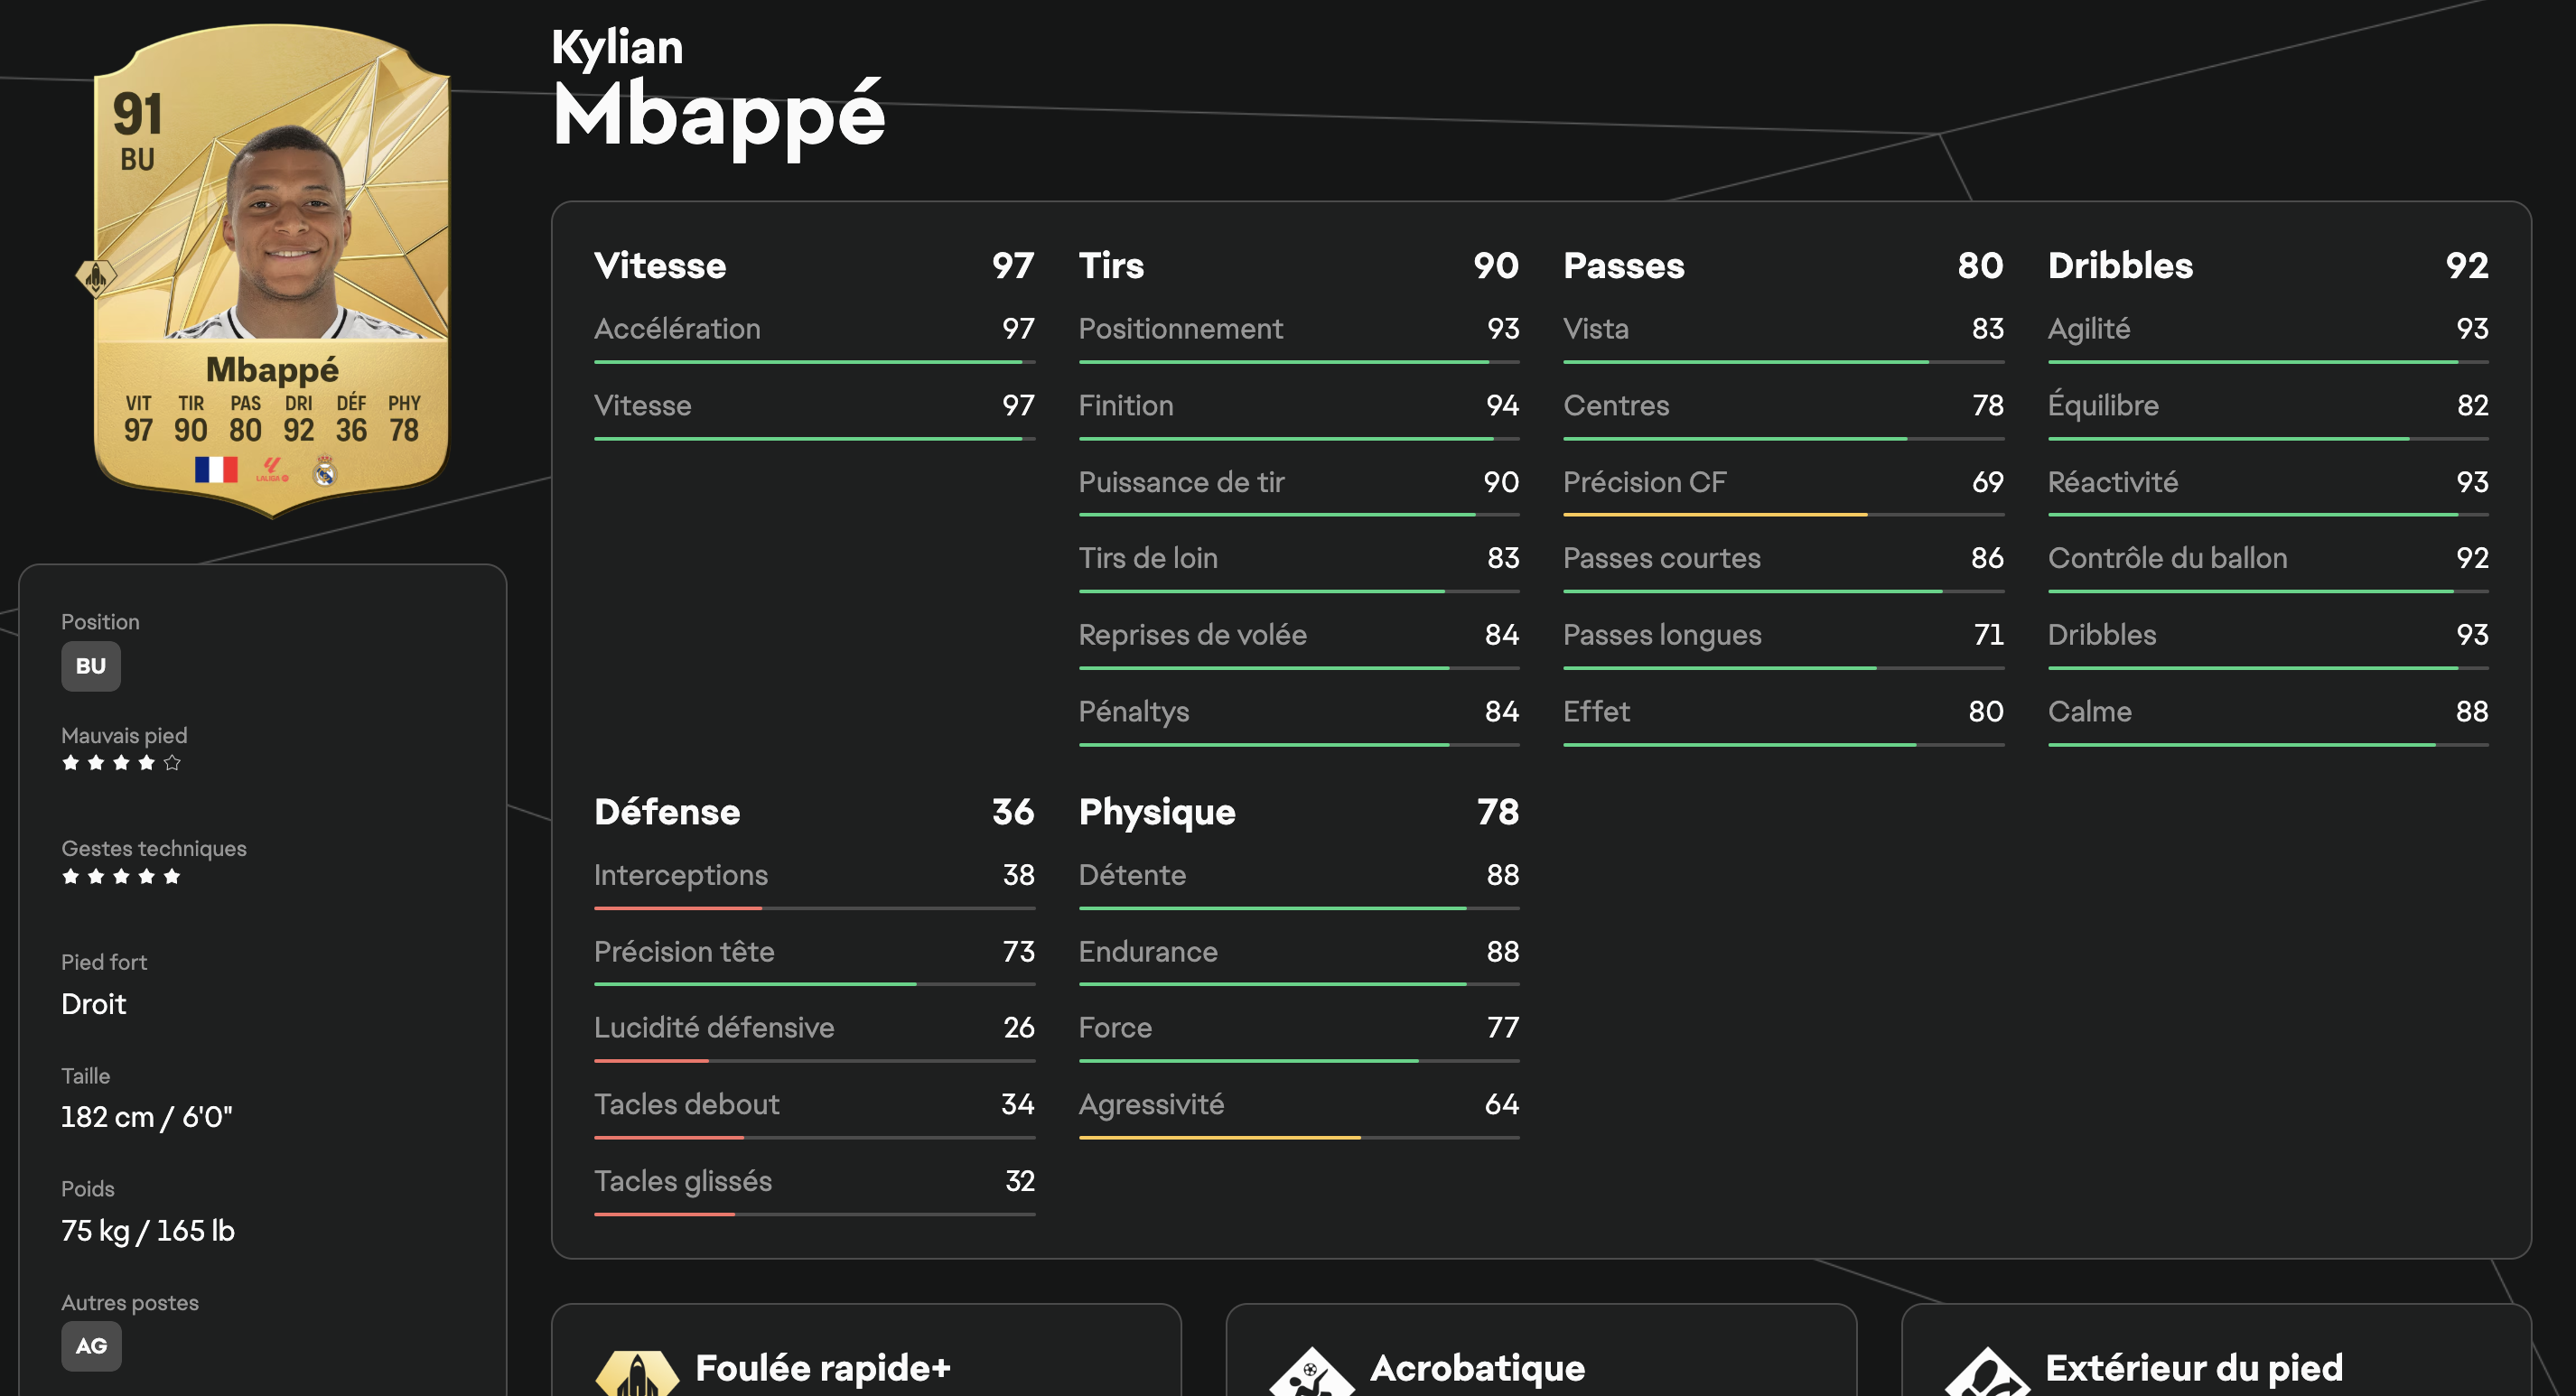

#Importation des données



In [ ]:
import pandas as  pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as p
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns

In [ ]:
table_fifa=pd.read_csv("male_players.csv")


In [ ]:
#Taille de la table
table_fifa.shape

(16161, 58)

In [ ]:
table_fifa.head()

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


#Aperçu et Nettoyage de la base de données

In [ ]:

import pandas as  pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as p
import matplotlib.pyplot as plt
from math import pi
import seaborn as sns

#Suppression des colonnes inutiles
colonne_supprimer=['play style','url','Alternative positions','Unnamed: 0','Unnamed: 0.1']
table_fifa=table_fifa.drop(colonne_supprimer,axis=1)
#Remplacer les valeurs manquantes pard es 0
table_fifa=table_fifa.fillna(0)
#Modification du poids et de la taille pour que ce soit plus lisible.
table_fifa['Weight']=table_fifa['Weight'].str.extract('(\d+)kg').astype(int)
table_fifa['Height']=table_fifa['Height'].str.extract('(\d+)cm').astype(int)
table_fifa.head()


,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Weight,Age,Nation,League,Team,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,...,75,25,France,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
1,2,Rodri,91,66,80,86,84,87,85,65,...,82,28,Spain,Premier League,Manchester City,0.0,0.0,0.0,0.0,0.0
2,4,Erling Haaland,91,88,92,70,81,45,88,80,...,94,24,Norway,Premier League,Manchester City,0.0,0.0,0.0,0.0,0.0
3,5,Jude Bellingham,90,80,87,83,88,78,83,81,...,75,21,England,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
4,7,Vini Jr.,90,95,84,81,91,29,69,95,...,73,24,Brazil,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0


# Partie 1: Répartition des joueurs  (4 Graphiques)

**Analyse du nombre de joueurs par ligue**

In [ ]:
#Tableau croisé pour identifier le nombre de joueurs par ligue
nb_joueurs_ligue = table_fifa.groupby('League')['Name'].count()

# Création d'un DataFrame avec la colonne 'NbJoueurs'
nb_joueurs_ligue_df = pd.DataFrame({'NbJoueurs': nb_joueurs_ligue})

# Affichage du DataFrame résultant
nb_joueurs_ligue_df.head(10)

,NbJoueurs
League,
1A Pro League,392
3. Liga,496
3F Superliga,299
A-League,225
Allsvenskan,373
Bundesliga,485
Bundesliga 2,503
CSL,449
CSSL,320


In [ ]:
fig = px.bar(nb_joueurs_ligue_df, x=nb_joueurs_ligue_df.index, y='NbJoueurs',
             title="Nombre de joueurs par league",
             labels={'index': 'Ligue', 'NbJoueurs': 'Nombre de joueurs'})
fig.update_layout(xaxis_title='Ligue', yaxis_title='Nombre de joueurs')
fig.show()

In [ ]:
#Nombre de joueurs par ligue
Nb_ligue= len(nb_joueurs_ligue)
Nb_ligue

45

**Analyse du nombre de joueurs par poste**

In [ ]:
#tableau croisé pour le nombre de joueurs. par poste
nb_joueurs_postition=table_fifa['Position'].value_counts()
nb_joueurs_postition_df=pd.DataFrame({'NbJoueurs': nb_joueurs_postition})
nb_joueurs_postition_df


,NbJoueurs
Position,
CB,2924
ST,2183
CM,1890
GK,1816
CDM,1330
RB,1281
LB,1214
LM,968
CAM,961


In [ ]:
#Nombre de poste
nb_poste=len(nb_joueurs_postition)
nb_poste

12

In [ ]:
#Graphique du nombre de joueurs par poste
fig = px.bar(nb_joueurs_postition_df, x=nb_joueurs_postition_df.index, y='NbJoueurs',
             title="Nombre de joueurs par position",
             labels={'index': 'Position', 'NbJoueurs': 'Nombre de joueurs'})
fig.update_layout(xaxis_title='Position', yaxis_title='Nombre de joueurs')
fig.show()

Permet d'identifier les rôles surpeuplés ou sous-représentés dans les équipes, pour trouver des niches pour les transferts.
Les défenseurs centraux et les attaquants  sont les positions les plus représentées

Analyse de la distribution des joueurs dans les 5 grand championnat

Anlayse du nombre de joueurs par tranche d'age et Analyser afin d'obserser dans quelle tranche d'âge se trouve le plus grand nombre de très bon joueurs afin d'orientée les recruteurs.

In [ ]:
#Table des joueurs qui ont uniquement plus de 85 de général
TresBonJoueur=table_fifa[table_fifa['OVR']>=85]
TresBonJoueur


,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Weight,Age,Nation,League,Team,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,...,75,25,France,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
1,2,Rodri,91,66,80,86,84,87,85,65,...,82,28,Spain,Premier League,Manchester City,0.0,0.0,0.0,0.0,0.0
2,4,Erling Haaland,91,88,92,70,81,45,88,80,...,94,24,Norway,Premier League,Manchester City,0.0,0.0,0.0,0.0,0.0
3,5,Jude Bellingham,90,80,87,83,88,78,83,81,...,75,21,England,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
4,7,Vini Jr.,90,95,84,81,91,29,69,95,...,73,24,Brazil,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,101,Aurélien Tchouaméni,85,73,69,79,78,82,82,74,...,82,24,France,LALIGA EA SPORTS,Real Madrid,0.0,0.0,0.0,0.0,0.0
88,101,Diogo Jota,85,82,82,75,84,57,79,85,...,70,27,Portugal,Premier League,Liverpool,0.0,0.0,0.0,0.0,0.0
89,101,Sandro Tonali,85,84,74,81,81,82,82,81,...,79,24,Italy,Premier League,Newcastle Utd,0.0,0.0,0.0,0.0,0.0
90,101,Ollie Watkins,85,85,83,73,80,50,83,79,...,70,28,England,Premier League,Aston Villa,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Séparation des ages et définition des tranche d'ages
bins = [16, 21, 26, 31, 36, 100]
table_fifa['Tranche'] = pd.cut(table_fifa['Age'], bins=bins, labels=['16-21', '21-25', '25-30', '30-35', '35+'])
table_fifa_tranche=table_fifa['Tranche'].value_counts()
table_fifa_tranche


,count
Tranche,
21-25,6186
25-30,4568
16-21,3290
30-35,1878
35+,239


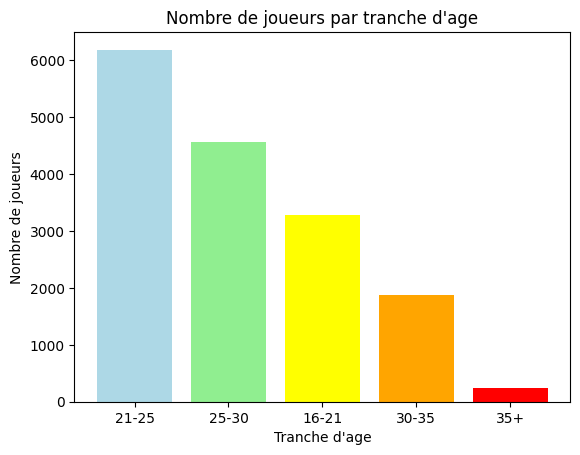

In [ ]:
#Graphique en bar du nombre de joueurs par tranche d'age
plt.bar(table_fifa_tranche_df.index, table_fifa_tranche_df['NbJoueurs'],color= ['lightblue', 'lightgreen', 'yellow', 'orange', 'red'])
plt.title("Nombre de joueurs par tranche d'age")
plt.xlabel("Tranche d'age")
plt.ylabel('Nombre de joueurs')

plt.show()

In [ ]:
#Nombre de joueurs par tranche d'age qui ont plus de 85 de général
joueursplus85= table_fifa[table_fifa['OVR'] > 85]
joueursplus85['Tranche'] = pd.cut(joueursplus85['Age'], bins=bins, labels=['16-21', '21-25', '25-30', '30-35', '35+'])
joueursplus85_tranche= joueursplus85['Tranche'].value_counts()
joueursplus85_tranche_df=pd.DataFrame({'NbJoueurs': joueursplus85_tranche})
joueursplus85_tranche_df




<ipython-input-192-02ffb3742957>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,NbJoueurs
Tranche,
25-30,24
21-25,19
30-35,14
16-21,4
35+,4


In [ ]:
# Ajout du pourcentage des joueurs qui ont plus de 85 de général dans la table croisé.
joueursplus85_total= joueursplus85_tranche_df['NbJoueurs'].sum()
joueursplus85_total
joueursplus85_tranche_df['Pourcentage'] = (joueursplus85_tranche_df['NbJoueurs'] / joueursplus85_total) * 100
joueursplus85_tranche_df




,NbJoueurs,Pourcentage
Tranche,,
25-30,24,36.923077
21-25,19,29.230769
30-35,14,21.538462
16-21,4,6.153846
35+,4,6.153846


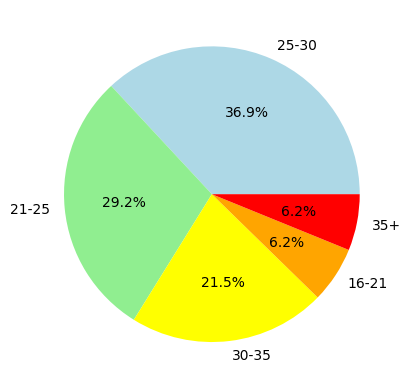

In [ ]:
#Graphique en cercle affichant le pourcentage de joueurs de plus de 85 de général par tranche d'age
plt.pie(
    joueursplus85_tranche_df['Pourcentage'],
    labels=joueursplus85_tranche_df.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'lightgreen', 'yellow', 'orange', 'red']
)
plt.show()

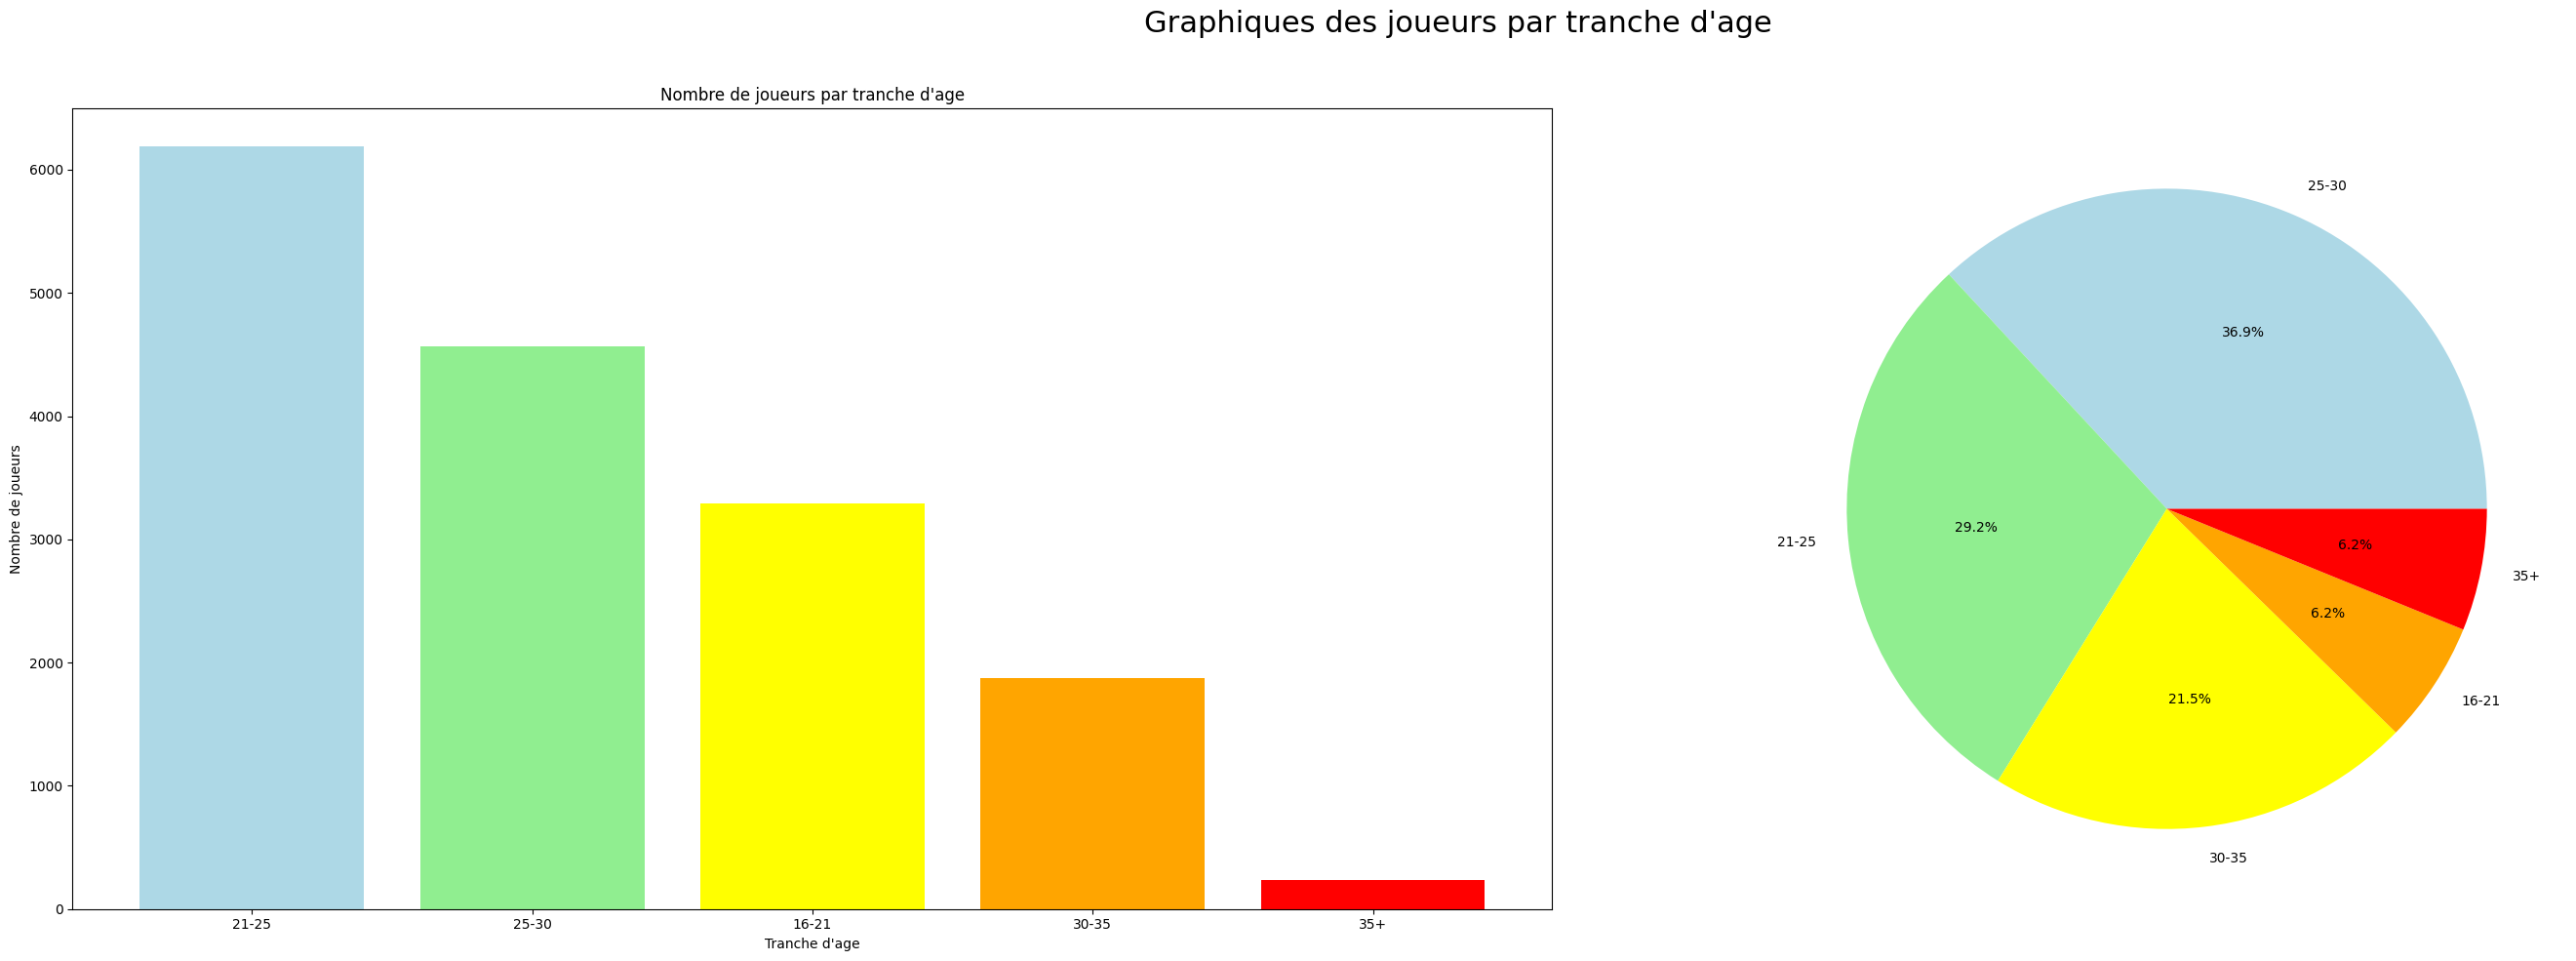

In [ ]:
#Fusion des deux graphiques
plt.figure(figsize= (30, 10)).suptitle("Graphiques des joueurs par tranche d'age", size=22)
plt.subplot(1, 2, 1)
plt.bar(table_fifa_tranche_df.index, table_fifa_tranche_df['NbJoueurs'],color= ['lightblue', 'lightgreen', 'yellow', 'orange', 'red'])
plt.title("Nombre de joueurs par tranche d'age")
plt.xlabel("Tranche d'age")
plt.ylabel('Nombre de joueurs')


plt.subplot(1, 2, 2)
plt.pie(
    joueursplus85_tranche_df['Pourcentage'],
    labels=joueursplus85_tranche_df.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'lightgreen', 'yellow', 'orange', 'red']
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



**Interprétation**

Permet aux recruteurs de prioriser les joueurs dans ces tranches pour maximiser les performances.

Les joueurs ayant une note supérieure à 85 sont également majoritairement dans les tranches 21-25 ans (29.2%) avec  et 25-30 ans (36.9%) .

#Partie 2: Analyse des performances et des notes générales (2 graphiques)

In [ ]:
#Graphique en violon affichant la distribution des joueurs dans les 5 grands championnat
import plotly.express as px



league=['LALIGA EA SPORTS','Premier League','Bundesliga',"Ligue 1 McDonald's",'Serie A Enilive']
les_5_grande_champions= table_fifa[table_fifa['League'].isin(league)]
df = pd.DataFrame(les_5_grande_champions)


fig = px.violin(
    df,
                x='League',
                y='OVR',
                color='League',
                box=True,
                points="all",
                title="Distribution de la note générale pour les 5 grands championnats masculin"
)


fig.show()

fig.write_html("violin_plot.html")

Permet au recruteur d'identifier dans quelle championnat le niveau est élevé. donc c'est idéal pour cibler les ligues avec des talents de haut niveau.

**Analyse de la corrélation entre les differents attributs afin de voir si quelles sont les statistiques qui reflète la note général des joueurs**

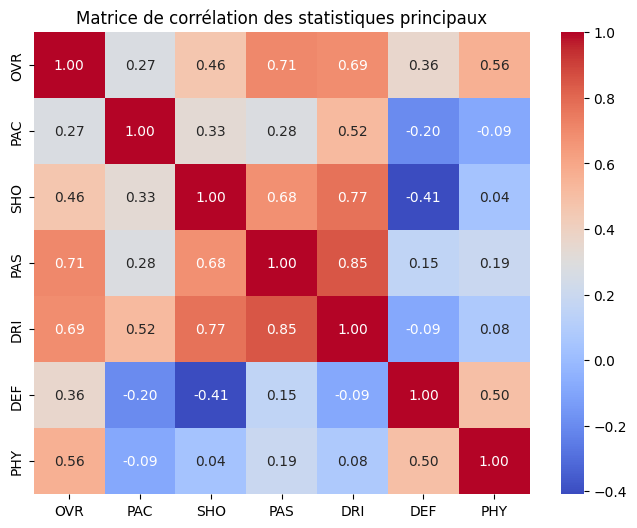

In [ ]:
StatsPrincipaux = ['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']
correlation_matrix = table_fifa[StatsPrincipaux ].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Matrice de corrélation des statistiques principaux')
plt.show()

Les attributs tels que la vitesse et les dribbles sont fortements corrélés avec la note général. Donc les meilleurs joueurs sont représenté grace à leur vitesse et leur qualité de dribbles.Permet d'orientée les recruteurs vers quelles styles de jeu.

#Partie 3: Performance par poste et identification des jeunes talents (5 graphqiues)

**Analyse des jeunes talents par poste selon les critères de chaque poste**

In [ ]:
table_fifa.columns

Index(['Rank', 'Name', 'OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY',
       'Acceleration', 'Sprint Speed', 'Positioning', 'Finishing',
       'Shot Power', 'Long Shots', 'Volleys', 'Penalties', 'Vision',
       'Crossing', 'Free Kick Accuracy', 'Short Passing', 'Long Passing',
       'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball Control',
       'Composure', 'Interceptions', 'Heading Accuracy', 'Def Awareness',
       'Standing Tackle', 'Sliding Tackle', 'Jumping', 'Stamina', 'Strength',
       'Aggression', 'Position', 'Weak foot', 'Skill moves', 'Preferred foot',
       'Height', 'Weight', 'Age', 'Nation', 'League', 'Team', 'GK Diving',
       'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes'],
      dtype='object')

In [ ]:
StatsPrincipauxMoyen_position=table_fifa.groupby('Position')[StatsPrincipaux ].mean()
StatsPrincipauxMoyen_position

,OVR,PAC,SHO,PAS,DRI,DEF,PHY
Position,,,,,,,
CAM,66.558793,69.941727,61.626431,64.302810,68.991675,43.977107,58.009365
CB,66.604993,59.885773,36.475034,50.033174,52.913475,66.371067,71.849521
CDM,66.981955,62.021805,52.371429,61.652632,63.975188,63.986466,69.357895
CM,65.912169,65.821693,58.194180,64.402116,66.982011,58.756085,64.933862
GK,64.747247,65.282489,63.281388,62.361784,66.120595,35.488436,63.645925
LB,65.747941,72.985173,46.250412,58.322076,63.391269,61.097199,65.014827
LM,66.634298,77.029959,60.740702,61.175620,68.573347,40.288223,58.352273
LW,66.565982,77.425220,61.944282,60.521994,69.448680,34.322581,56.501466
RB,65.901639,73.093677,45.773614,57.712724,63.129586,61.483997,65.992194


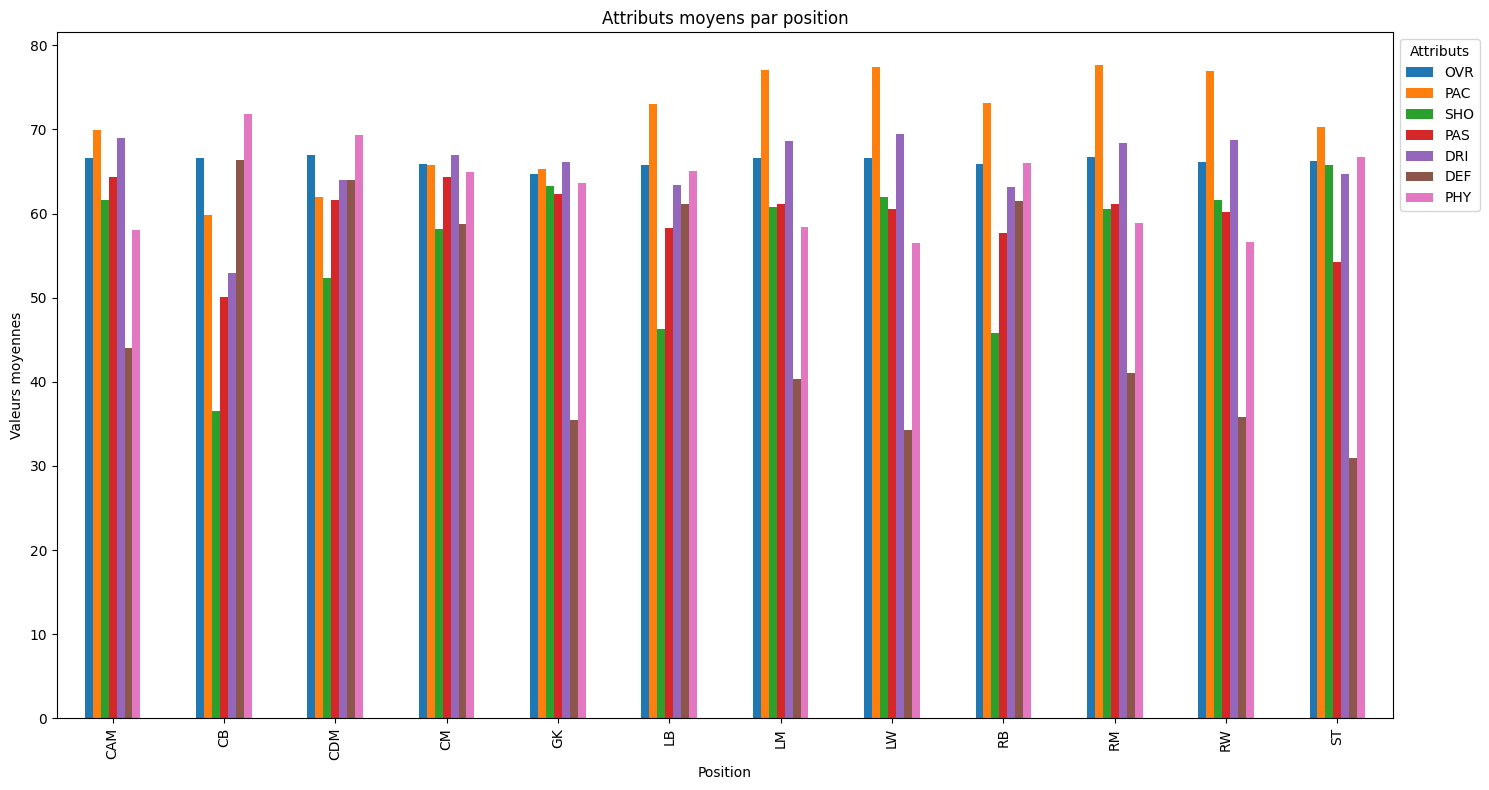

In [ ]:
StatsPrincipauxMoyen_position.plot(kind='bar', figsize=(15, 8))
plt.title('Attributs moyens par position')
plt.ylabel('Valeurs moyennes')
plt.xlabel('Position')
plt.legend(title='Attributs', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()



Les défenseurs se distinguent par leurs compétences en physique et defense, tandis que les attaquants brillent en vitesse et physique.
Permet de définir des profils idéaux pour chaque poste

In [ ]:
jeunes = table_fifa[table_fifa['Age'] < 21]

In [ ]:
jeunes

,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,...,Weight,Age,Nation,League,Team,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
167,222,Gavi,83,76,66,78,85,68,70,77,...,70,20,Spain,LALIGA EA SPORTS,FC Barcelona,0.0,0.0,0.0,0.0,0.0
253,322,Savinho,82,88,72,77,84,30,53,90,...,71,20,Brazil,Premier League,Manchester City,0.0,0.0,0.0,0.0,0.0
285,458,Balde,81,91,48,73,78,75,64,90,...,69,20,Spain,LALIGA EA SPORTS,FC Barcelona,0.0,0.0,0.0,0.0,0.0
349,458,Lamine Yamal,81,82,75,76,82,23,48,84,...,65,17,Spain,LALIGA EA SPORTS,FC Barcelona,0.0,0.0,0.0,0.0,0.0
457,577,Warren Zaïre-Emery,80,79,68,77,80,75,78,80,...,68,18,France,Ligue 1 McDonald's,Paris SG,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16151,17717,Min Zixi,47,61,38,43,50,40,44,62,...,60,19,China PR,CSL,Wuhan Three Towns,0.0,0.0,0.0,0.0,0.0
16152,17717,Ning Fangze,47,50,37,45,46,38,45,49,...,63,19,China PR,CSL,Zhejiang Pro,0.0,0.0,0.0,0.0,0.0
16153,17717,Park Hyung Woo,47,60,39,40,52,20,40,61,...,71,20,Korea Republic,K League 1,Pohang Steelers,0.0,0.0,0.0,0.0,0.0
16154,17717,Park Jin Hong,47,65,36,43,47,36,58,68,...,75,19,Korea Republic,K League 1,Incheon United,0.0,0.0,0.0,0.0,0.0


Les meilleurs jeunes attaquants selon les critères suivants:
- Vitesse (Acceleration, Sprint Speed)
- Capacités de dribble (Dribbling, Ball Control)
- Capacité à finir les actions (Finishing, Shot Power)

In [ ]:
attaquants = jeunes[jeunes['Position'].isin(['ST', 'LW', 'RW'])]


In [ ]:
attaquants['score'] = (attaquants['Acceleration'] + attaquants['Sprint Speed'] +
                                attaquants['Dribbling'] + attaquants['Ball Control'] +
                                attaquants['Finishing'] + attaquants['Shot Power'])/6

topjeunesattaquants=attaquants[['Name', 'OVR', 'score']]
topjeunesattaquants=topjeunesattaquants.sort_values(by='score', ascending=False).head(10)
topjeunesattaquants



<ipython-input-142-88375e65ba0e>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Name,OVR,score
1021,Mathys Tel,77,82.666667
1273,Vitor Roque,76,82.166667
253,Savinho,82,82.000000
956,Endrick,77,81.500000
349,Lamine Yamal,81,80.666667
1125,Abdul Fatawu,76,79.500000
2191,Yoan Bonny,73,78.666667
959,Youssoufa Moukoko,77,78.500000
1983,Ernest Nuamah,74,78.500000
2373,Karim Konaté,73,77.833333


Les meilleurs jeunes meilleurs de terrain selon les critères suivants:
- Vision et passes (Vision, Short Passing, Long Passing , Curve)
- Contrôle et dribble (Ball Control, Dribbling, Agility)
- Défense et récupération
(Interceptions, Def Awareness)
-Endurance(Stamina)

In [ ]:
milieux = jeunes[jeunes['Position'].isin(['CM', 'CDM', 'CAM'])]


In [ ]:
#Calcul de la somme des score
milieux['Score_M'] = (milieux['Vision'] + milieux['Short Passing'] + milieux['Long Passing'] +
                                         milieux['Curve'] + milieux['Ball Control'] + milieux['Dribbling'] +
                                         milieux['Agility'] + milieux['Interceptions'] + milieux['Def Awareness'] +
                                         milieux['Stamina'])/10
topmilieux=milieux[['Name', 'OVR', 'Score_M']]
topmilieux=topmilieux.sort_values(by='Score_M', ascending=False).head(10)
topmilieux

<ipython-input-144-5074ae0a8e56>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Name,OVR,Score_M
167,Gavi,83,80.2
523,João Neves,79,79.0
1316,Arthur Vermeeren,76,78.3
457,Warren Zaïre-Emery,80,77.9
938,Kobbie Mainoo,77,76.8
799,Adam Wharton,78,76.4
695,Arda Güler,78,74.8
1913,Hugo Larsson,74,73.9
2497,Aleksandar Pavlović,73,72.9
1499,Romeo Lavia,75,72.5


Les meilleurs jeunes defenseurs de terrain selon les critères suivants:

- Vitesse et récupération : (Acceleration, Sprint Speed)
- Tacles et interceptions : (Standing Tackle, Sliding Tackle, Interceptions)
- Marquage et présence physique( Def Awareness, Heading Accuracy, Strength, Jumping)
-Endurance : Stamina

In [ ]:
defenseurs = jeunes[jeunes['Position'].isin(['CB', 'LB', 'RB'])]

defenseurs['Score_D'] = (
    defenseurs['Acceleration'] + defenseurs['Sprint Speed'] +
    defenseurs['Standing Tackle'] + defenseurs['Sliding Tackle'] +
    defenseurs['Interceptions'] + defenseurs['Def Awareness'] +
    defenseurs['Heading Accuracy'] + defenseurs['Strength'] +
    defenseurs['Jumping'] + defenseurs['Stamina']
)/10

topdefenseurs = defenseurs[['Name', 'OVR', 'Score_D']]

topdefenseurs = topdefenseurs.sort_values(by='Score_D', ascending=False).head(10)

topdefenseurs


<ipython-input-145-60e62ef12f30>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Name,OVR,Score_D
603,António Silva,79,80.2
665,Ousmane Diomande,78,79.2
958,Mosquera,77,78.4
285,Balde,81,77.0
802,Leny Yoro,78,76.3
2333,Jorrel Hato,73,75.9
3446,Soumaila Coulibaly,71,75.2
1104,Zeno Debast,76,74.2
2523,Leopold Querfeld,73,74.0
919,Milos Kerkez,77,73.9


Les meilleurs jeunes gardien de terrain selon les critères suivants:
- Plongeon et gestion des tirs (GK Diving,GK Reflexes )
- Prise en main et distribution (GK Handling, GK Kicking )
- Positionnement et anticipation (GK Positioning )
Compétences en jeu aérien (Heading Accuracy )

In [ ]:
gardiens = jeunes[jeunes['Position'] == 'GK']

gardiens['Score_GK'] = (gardiens['GK Diving'] + gardiens['GK Reflexes'] + gardiens['GK Handling'] + gardiens['GK Kicking'] + gardiens['GK Positioning'] + gardiens['Heading Accuracy']
)/6


topgardiens = gardiens[['Name', 'OVR', 'Score_GK']]
topgardiens = topgardiens.sort_values(by='Score_GK', ascending=False).head(10)
topgardiens


<ipython-input-141-f04180539524>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Name,OVR,Score_GK
766,Guillaume Restes,78,66.833333
5853,Diogo Pinto,68,59.500000
4838,James Beadle,69,59.500000
4902,Diego Callai,69,58.666667
5379,Rome-Jayden Owusu-Oduro,69,58.500000
5756,Chris Brady,68,58.500000
6493,Gabriel Slonina,68,57.333333
7413,Robin Risser,67,56.833333
8467,Randall Rodríguez,66,56.666667
8114,Ewen Jaouen,66,56.500000


**Graphique des meilleurs jeunes joueurs selon les critères:**

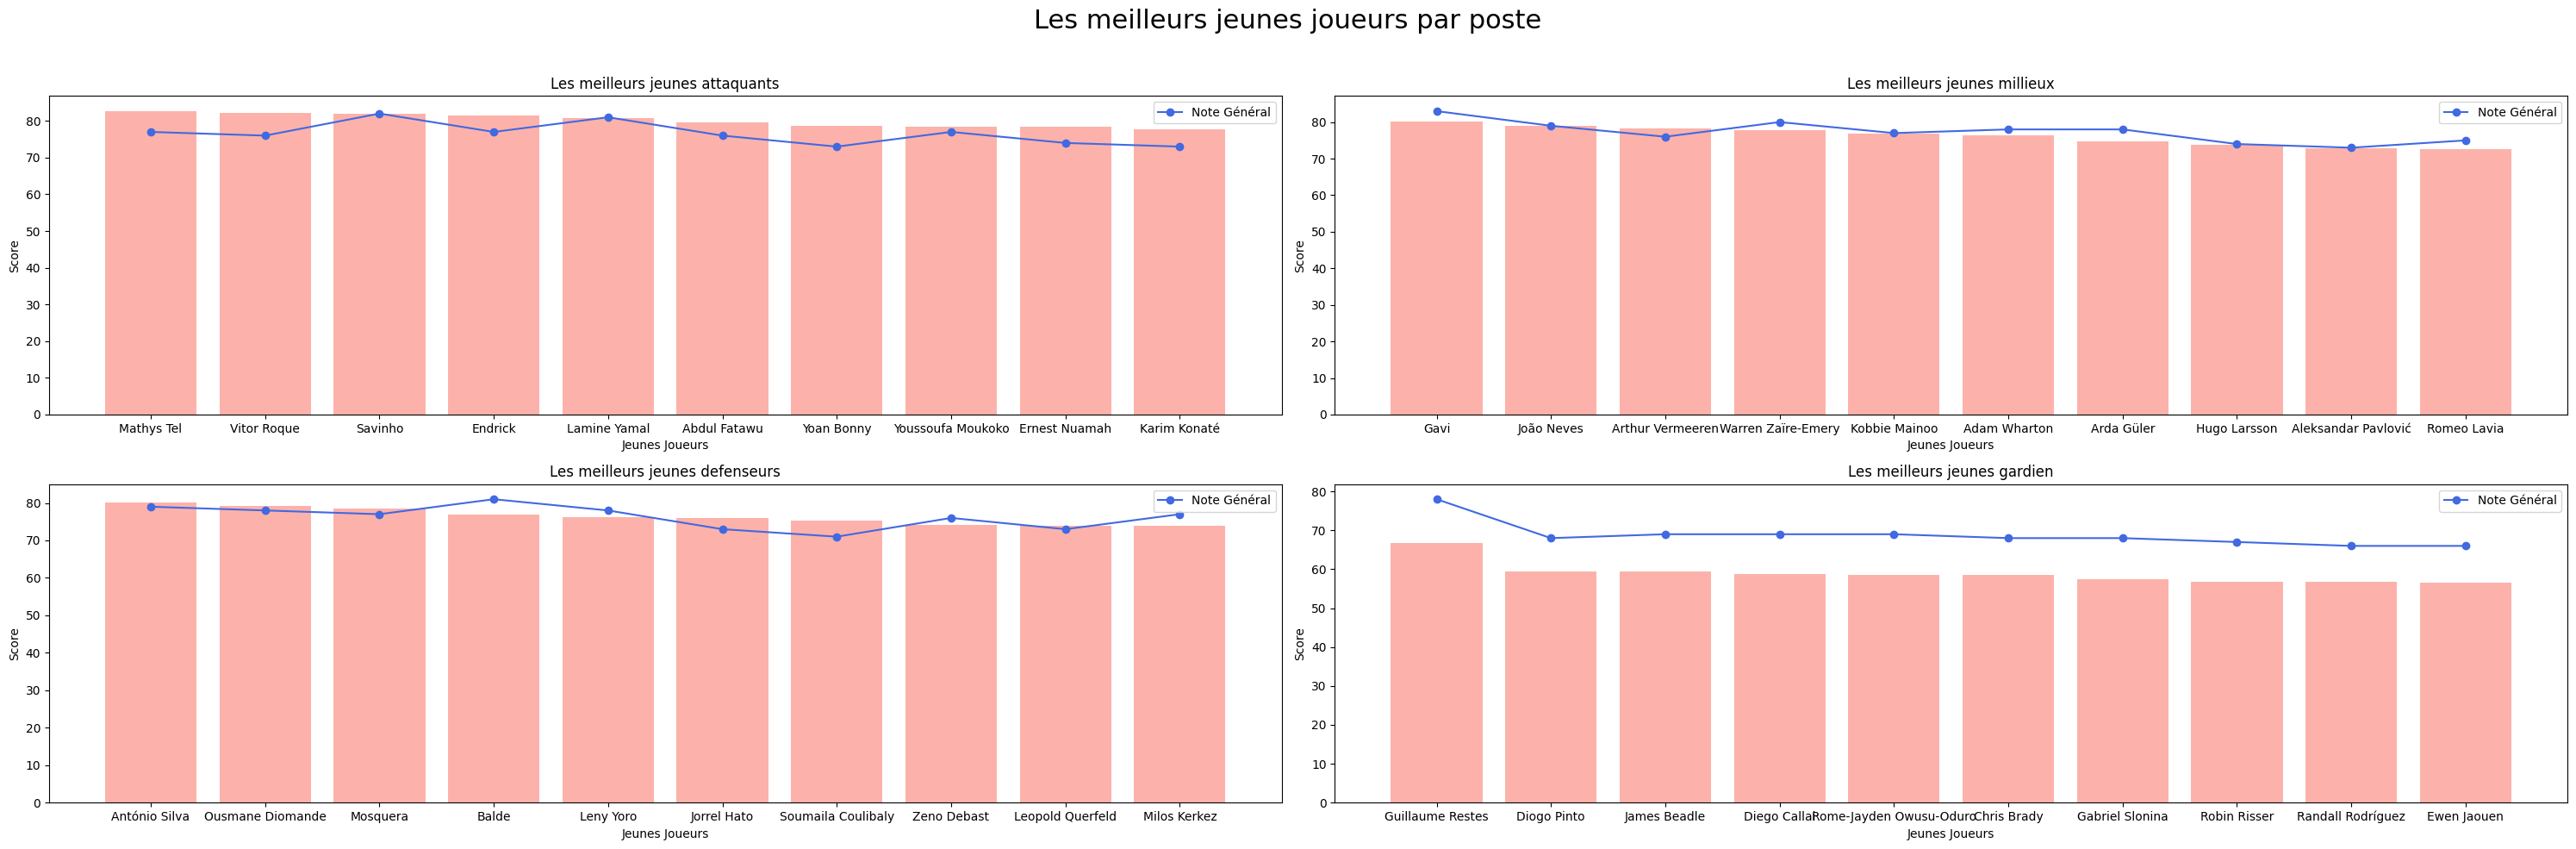

In [ ]:
plt.figure(figsize= (30, 10)).suptitle("Les meilleurs jeunes joueurs par poste", size=22)

plt.subplot(2, 2, 1)
plt.bar(topjeunesattaquants["Name"], topjeunesattaquants["score"], color='salmon', alpha=0.6)
plt.plot(topjeunesattaquants["Name"], topjeunesattaquants["OVR"], label='Note Général', color='royalblue', marker='o')
plt.title('Les meilleurs jeunes attaquants')
plt.xlabel('Jeunes Joueurs')
plt.ylabel('Score')
plt.legend(loc='upper right')

plt.subplot(2, 2, 2)
plt.bar(topmilieux["Name"], topmilieux['Score_M'], color='salmon', alpha=0.6)
plt.plot(topmilieux["Name"], topmilieux["OVR"], label='Note Général', color='royalblue', marker='o')
plt.title('Les meilleurs jeunes millieux')
plt.xlabel('Jeunes Joueurs')
plt.ylabel('Score')
plt.legend(loc='upper right')


plt.subplot(2, 2, 3)
plt.bar(topdefenseurs["Name"], topdefenseurs['Score_D'], color='salmon', alpha=0.6)
plt.plot(topdefenseurs["Name"], topdefenseurs["OVR"], label='Note Général', color='royalblue', marker='o')
plt.title('Les meilleurs jeunes defenseurs')
plt.xlabel('Jeunes Joueurs')
plt.ylabel('Score')
plt.legend(loc='upper right')

plt.subplot(2, 2, 4)
plt.bar(topgardiens["Name"], topgardiens['Score_GK'], color='salmon', alpha=0.6)
plt.plot(topgardiens["Name"], topgardiens["OVR"], label='Note Général', color='royalblue', marker='o')
plt.title('Les meilleurs jeunes gardien')
plt.xlabel('Jeunes Joueurs')
plt.ylabel('Score')
plt.legend(loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



#A voir: La comparaison des performances par ligue et position (2 Graphiques)

In [ ]:

fig = px.bar(
    les_5_grande_champions,
    x='League',
    y='OVR',
    color='Position',  # Couleur par position
    title="Performance Moyenne des Joueurs par Position et Ligue",
    labels={'OVR': 'Score de Performance (OVR)', 'League': 'Ligue'},
    barmode='group'  # Affichage en mode groupé
)

# Affichage du graphique
fig.show()

**Graphique en carte de chaleur pour les performance de chaque league par position**

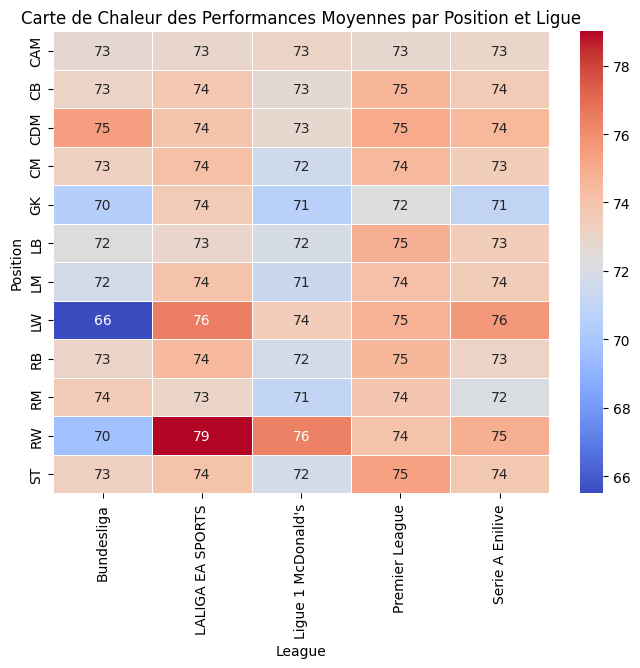

In [ ]:

# Création de la table de pivot pour la heatmap
heatmap_data = les_5_grande_champions.pivot_table(values='OVR', index='Position', columns='League')

# Affichage de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Carte de Chaleur des Performances Moyennes par Position et Ligue')
plt.show()

#Insights clé:
Recrutements:
- Prioriser les joueurs dans les tranches d'âge 21-30 ans.
- Cibler les ligues comme la Premier League et la LALIGA, qui regorgent de talents de haut niveau.
-Prioriser les jeunes ayant une bonne qualité de dribble et de vitesse


Jeunes Talents :
- Investir dans des jeunes prometteurs tels que Victor Roque ou Mathys Tel, en utilisant les scores calculés pour chaque poste.
